# Lab 6: Raster + Terrain Visualization

Yunsik Kim

## Part 1: Setup + DEM loading

In [1]:
# import os
# import earthpy as et

# data_dir = et.data.get_data('vignette-elevation')

# dem_path = os.path.join(data_dir, 'pre_DTM.tif')
# print(dem_path)

### 1.1. Import + environment check

In [2]:
import os
import earthpy as et
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

import rasterio as rio
import earthpy.plot as ep
import earthpy.spatial as es

print('numpy:', np.__version__)
print('matplotlib:', matplotlib.__version__)
print('rasterio:', rio.__version__)
# print('earthpy:', et.__version__)

try:
    import richdem as rd
    print('richdem:', rd.__version__)
except Exception as e:
    print('richdem: NOT INSTALLED (ok) ->', e)

numpy: 2.4.2
matplotlib: 3.10.8
rasterio: 1.4.4
richdem: NOT INSTALLED (ok) -> module 'richdem' has no attribute '__version__'


### 1.2. Open and inspect the DEM

In [3]:
DEM_PATH = 'earth-analytics/pre_DTM.tif'

with rio.open(DEM_PATH) as src:
    dem = src.read(1).astype('float32')
    profile = src.profile
    crs = src.crs
    transform = src.transform
    nodata = src.nodata

print('CRS:', crs)
print('Shape (rows, cols):', dem.shape)
print('Resolution:', (transform.a, -transform.e))
print('Nodata:', nodata)

# Mask nodata (and any other invalid values you decide)
if nodata is not None:
    dem[dem == nodata] = np.nan

print('Min/Max (masked):', np.nanmin(dem), np.nanmax(dem))

CRS: EPSG:32613
Shape (rows, cols): (2000, 4000)
Resolution: (1.0, 1.0)
Nodata: -3.4028234663852886e+38
Min/Max (masked): 1676.21 2087.43


## Part 2: Visualize elevation (color ramps + value stretch)
### 2.1. Plot the DEM with different colormaps

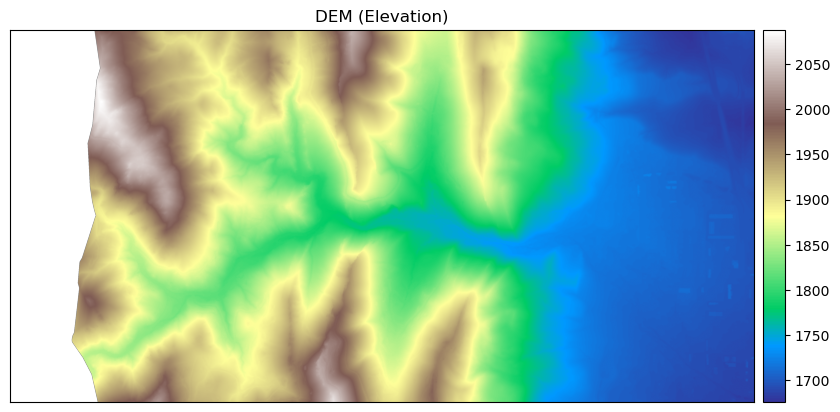

In [4]:
# Simple DEM plot (EarthPy helper)
ep.plot_bands(
    dem,
    cmap='terrain',     # try: 'gist_earth', 'viridis', 'cividis'
    title='DEM (Elevation)',
    figsize=(10, 6),
)
plt.show()

### 2.2. Apply a percentile stretch (recommended for prettier maps)

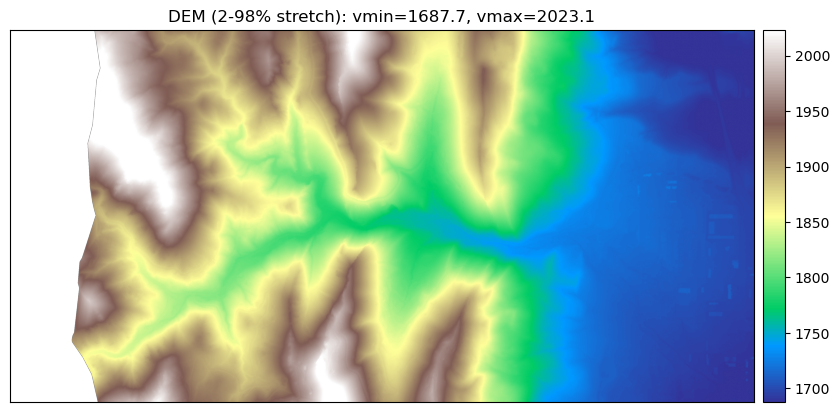

In [5]:
# Percentile stretch (2nd-98th is a common starting point)
vmin, vmax = np.nanpercentile(dem, (2, 98))

ep.plot_bands(
    dem,
    cmap='terrain',
    vmin=vmin,
    vmax=vmax,
    title=f'DEM (2-98% stretch): vmin={vmin:.1f}, vmax={vmax:.1f}',
    figsize=(10, 6),
)
plt.show()

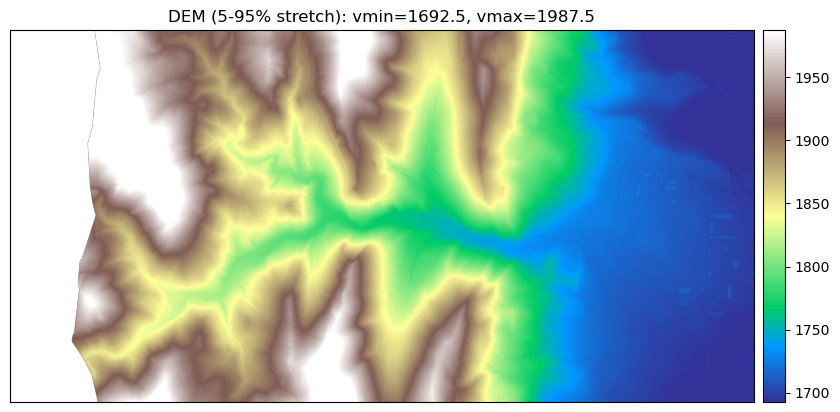

In [19]:
# Percentile stretch (2nd-98th is a common starting point)
vmin, vmax = np.nanpercentile(dem, (5, 95))

ep.plot_bands(
    dem,
    cmap='terrain',
    vmin=vmin,
    vmax=vmax,
    title=f'DEM (5-95% stretch): vmin={vmin:.1f}, vmax={vmax:.1f}',
    figsize=(10, 6),
)
plt.show()

### 2.3. (Optional) Plot a histogram to justify your stretch

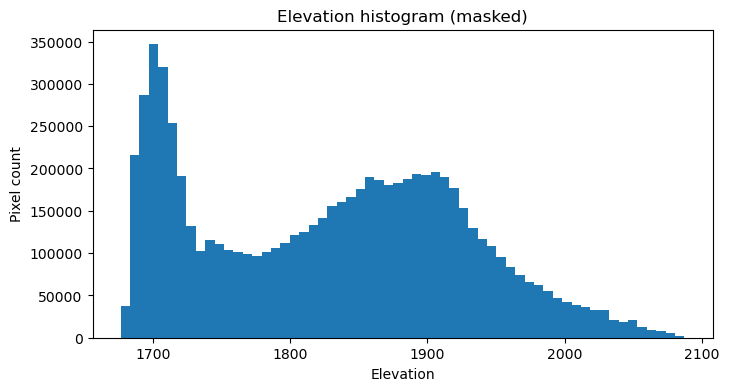

In [6]:
vals = dem[np.isfinite(dem)]
plt.figure(figsize=(8, 4))
plt.hist(vals, bins=60)
plt.title("Elevation histogram (masked)")
plt.xlabel("Elevation")
plt.ylabel("Pixel count")
plt.show()

## Part 3. Slope + aspect (terrain derivatives)
### 3.1. Compute slope and aspect with richdem (recommended)

In [7]:
# Requires: conda install -c conda-forge richdem
import richdem as rd

# Load DEM with georeferencing (best practice)
dem_rd = rd.rdarray(dem, no_data=nodata)

# Slope options:
# - 'slope_degrees' (0-90) is easy to interpret
# - 'slope_riserun' (rise/run) can be converted to percent slope
slope_deg = rd.TerrainAttribute(dem_rd, attrib="slope_degrees")

# Aspect is a circular direction (0-360 degrees, often 0/360 = North)
aspect = rd.TerrainAttribute(dem_rd, attrib="aspect")

Warning! No geotransform defined. Choosing a standard one! (Top left cell's top let corner at <0,0>; cells are 1x1.)
Warning! No geotransform defined. Choosing a standard one! (Top left cell's top let corner at <0,0>; cells are 1x1.)
Warning! No geotransform defined. Choosing a standard one! (Top left cell's top let corner at <0,0>; cells are 1x1.)
Warning! No geotransform defined. Choosing a standard one! (Top left cell's top let corner at <0,0>; cells are 1x1.)



A Slope calculation (degrees)
C Horn, B.K.P., 1981. Hill shading and the reflectance map. Proceedings of the IEEE 69, 14–47. doi:10.1109/PROC.1981.11918

t Wall-time = 0.151709======================= ] (99% - 0.0s - 1 threads)

A Aspect attribute calculation
C Horn, B.K.P., 1981. Hill shading and the reflectance map. Proceedings of the IEEE 69, 14–47. doi:10.1109/PROC.1981.11918

t Wall-time = 0.317358======================= ] (99% - 0.0s - 1 threads)


### 3.2. Plot slope and aspect

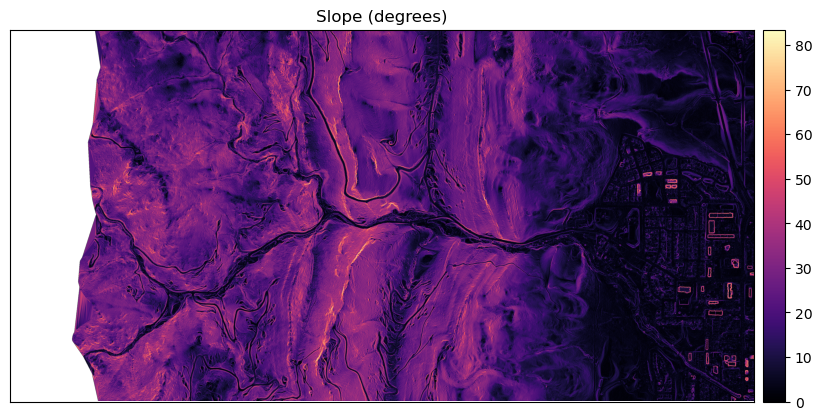

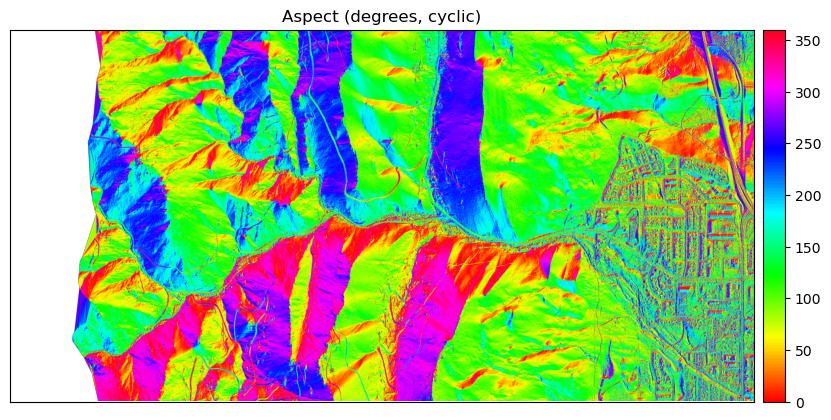

In [8]:
# Slope
ep.plot_bands(
    np.array(slope_deg),
    cmap='magma',
    title='Slope (degrees)',
    figsize=(10, 6),
)
plt.show()

# Aspect (use a cyclic colormap if available)
ep.plot_bands(
    np.array(aspect),
    cmap='hsv',    # try: 'hsv' if twilight is not available
    title='Aspect (degrees, cyclic)',
    figsize=(10, 6),
)
plt.show()

## Part 4. Hillshade (illumination + shading)
### 4.1. Create hillshade with EarthPy

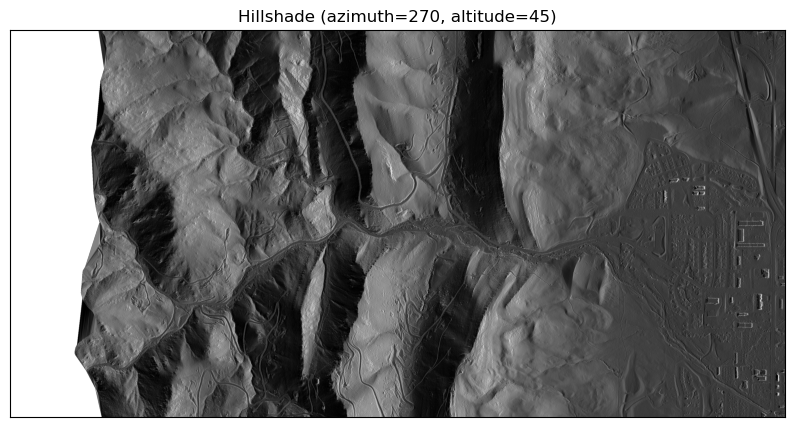

In [20]:
# EarthPy hillshade from the DEM array
# azimuth: 0=N, 90=E, 180=S, 270=W (default often ~315)
# altitude: 0-90 (higher = less shadow)
azimuth = 270
altitude = 45

hill = es.hillshade(dem, azimuth=azimuth, altitude=altitude)
ep.plot_bands(
    hill,
    cmap="Greys",
    cbar=False,
    title=f"Hillshade (azimuth={azimuth}, altitude={altitude})",
    figsize=(10, 6),
)
plt.show()

### 4.2. (Optional) Compare multiple hillshades

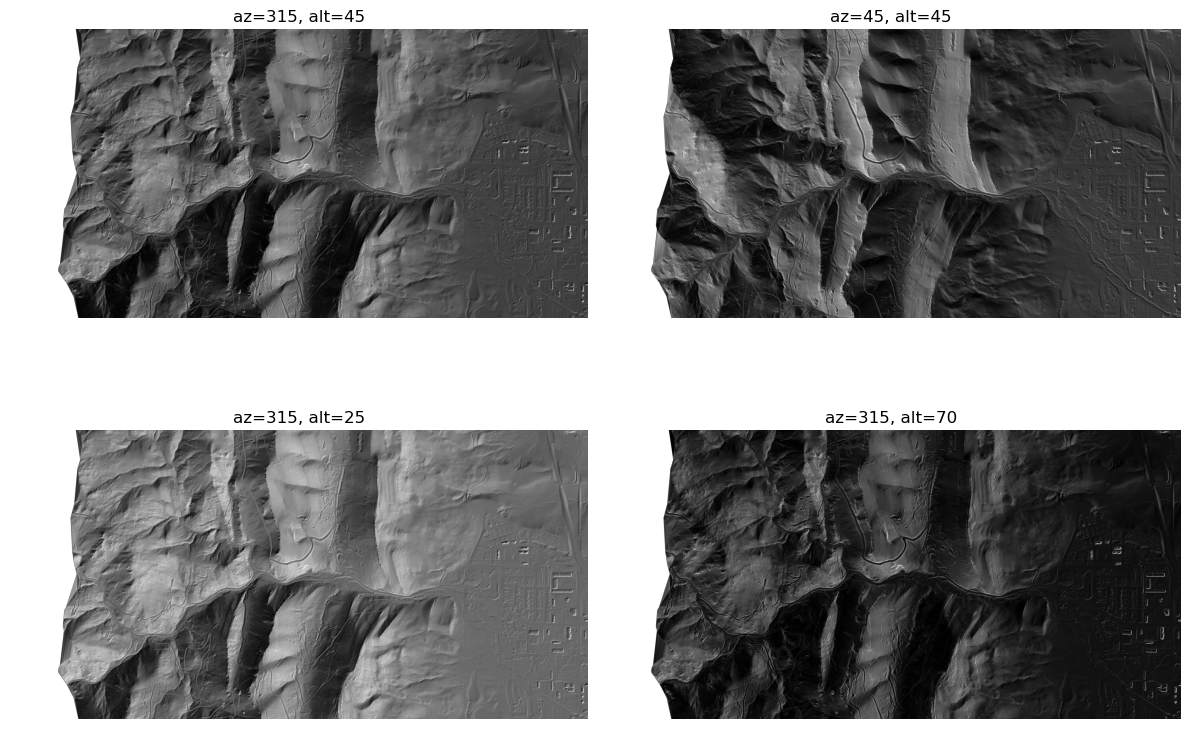

In [10]:
# Compare 4 lighting settings (small multiples)
settings = [(315, 45), (45, 45), (315, 25), (315, 70)]

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.ravel()

for ax, (az, alt) in zip(axes, settings):
    hs = es.hillshade(dem, azimuth=az, altitude=alt)
    ax.imshow(hs, cmap="Greys")
    ax.set_title(f"az={az}, alt={alt}")
    ax.set_axis_off()

plt.tight_layout()
plt.show()

## Part 5. DEM + hillshade composite (polished terrain map)
### 5.1. Overlay hillshade on top of colored DEM

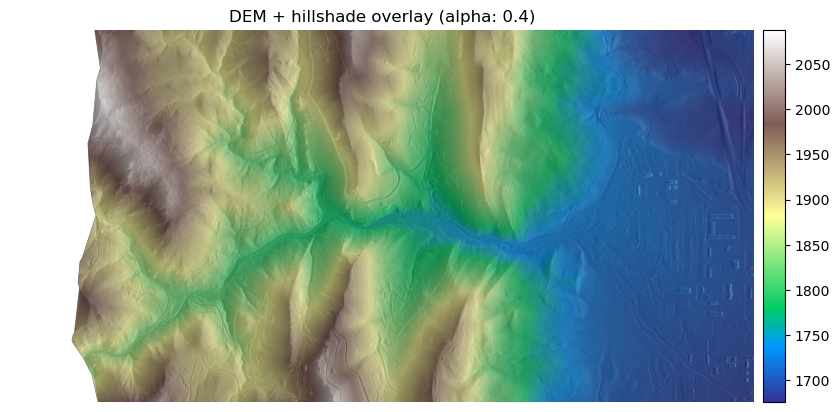

In [22]:
# 1) Plot the DEM as the base (color)
fig, ax = plt.subplots(figsize=(10, 6))
alpha = 0.4
ep.plot_bands(
    dem,
    ax=ax,
    cmap='terrain',
    title=f'DEM + hillshade overlay (alpha: {alpha})',
    cbar=True,
)

# 2) Overlay hillshade (grayscale) with transparency
ax.imshow(hill, cmap='Greys', alpha=alpha)
ax.set_axis_off()

plt.show()

### 5.2. (Optional) Export the figure

In [12]:
# Save at high resolution for reports / portfolio
out_png = 'outputs/dem_hillshade.png'
os.makedirs('outputs', exist_ok=True)

fig.savefig(out_png, dpi=500, bbox_inches='tight')
print('Saved:', out_png)

Saved: outputs/dem_hillshade.png


## Part 6. (Optional) Write derived rasters to GeoTIFF

In [13]:
# Write GeoTIFFs with rasterio (keeps CRS, transform, etc.)
os.makedirs('outputs', exist_ok=True)

def write_tif(path, arr, profile):
    prof = profile.copy()
    prof.update(dtype='float32', count=1, nodata=np.nan)
    with rio.open(path, 'w', **prof) as dst:
        dst.write(arr.astype('float'), 1)

write_tif('outputs/slope_degrees.tif', np.array(slope_deg), profile)
write_tif('outputs/aspect_degrees.tif', np.array(aspect), profile)
write_tif('outputs/hillshade.tif', hill.astype('float32'), profile)

print('Wrote GeoTIFFs to outputs/')

Wrote GeoTIFFs to outputs/
